<a href="https://colab.research.google.com/github/slimisgit/grokking/blob/tests_core/report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

статья: [url text](https://www.lesswrong.com/posts/bTgTggoKRGLRF4enD/grokking-revisited-reverse-engineering-grokking-modulo)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt #графики
import numpy as np
import os
from dataclasses import dataclass, asdict
import json
from google.colab import userdata

#создание дата сета
def create_dataset(N, fraction_train, seed=42):
    np.random.seed(seed)
    all_pairs = [(x, y) for x in range(N) for y in range(N)]
    np.random.shuffle(all_pairs)
    all_pairs = np.array(all_pairs)

    total_size = len(all_pairs)
    train_size = int(total_size * fraction_train)
    test_size = total_size - train_size

    train_pairs = all_pairs[:train_size]
    test_pairs = all_pairs[train_size:]

    def pairs_to_dataset(pairs):
        xs = torch.tensor(pairs[:, 0], dtype=torch.long)
        ys = torch.tensor(pairs[:, 1], dtype=torch.long)
        targets = (xs + ys) % N
        return xs, ys, targets

    train_x, train_y, train_t = pairs_to_dataset(train_pairs)
    test_x, test_y, test_t = pairs_to_dataset(test_pairs)
    train_seq = torch.stack([train_x, train_y], dim=1)
    train_targets = train_t
    test_seq = torch.stack([test_x, test_y], dim=1)
    test_targets = test_t

    return train_seq, train_targets, test_seq, test_targets


#модель
class LSTMModelOneHot(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(LSTMModelOneHot, self).__init__()
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size


        self.W_ih = nn.Linear(vocab_size, 4*hidden_size, bias=True)  #это типо 4 матрицы в одной для скорости
        self.W_hh = nn.Linear(hidden_size, 4*hidden_size, bias=True)
        self.fc1 = nn.Linear(hidden_size,  vocab_size, bias=False)

        self.relu = nn.ReLU()

    #один шаг по времени(вообще по времени в батче,но у нас батч=эпоха)
    def forward(self, x_seq):

        batch_size, seq_len = x_seq.size()
        device = x_seq.device

        #представление батча в onehot
        x_onehot = torch.zeros(batch_size, seq_len, self.vocab_size, device=device)
        x_onehot.scatter_(2, x_seq.unsqueeze(2), 1)

        #начальные долгосрочная и короткосрочная память
        h = torch.zeros(batch_size, self.hidden_size, device=device)
        c = torch.zeros(batch_size, self.hidden_size, device=device)


        for t in range(seq_len):
            #типо времени в LSTM (тут или 0 или 1)
            x_t = x_onehot[:, t, :]

            #логика LSTM,но т.к матрицы склеены в одну читать невозможно
            gates = self.W_ih(x_t) + self.W_hh(h)
            i = torch.sigmoid(gates[:, 0:self.hidden_size])  # input gate
            f = torch.sigmoid(gates[:, self.hidden_size:2*self.hidden_size])  # forget gate
            g = torch.tanh(gates[:, 2*self.hidden_size:3*self.hidden_size]) # candidate gate
            o = torch.sigmoid(gates[:, 3*self.hidden_size:4*self.hidden_size]) # output gate

            #логика долгосрочной памяти
            c = f * c + i * g

            h = torch.tanh(c)*o #

        logits = self.fc1(h)

        return logits

In [2]:
# класс хранящий данные о том как отработала модель
@dataclass
class Grokking_Data:
    seed: int

    train_losses: list
    train_accuracies: list
    test_losses: list
    test_accuracies: list

    N: int = 113
    fraction_train: float = 0.3
    lr: float = 1e-3
    weight_decay: float = 1.0
    betas: tuple = (0.9, 0.98)
    epochs: int = 100000
    checkpoint_interval: int = 200

    # характеристики гроккинга
    first_train_high_acc_epoch: int = -1
    first_test_high_acc_epoch: int = -1
    test_loss_peak_epoch: int = -1
    test_loss_peak: float = -1.0
    grokking: bool = False
    plate_length: int = 0

    weights_path: str = ""

    def save(self, folder="results", model=None):

        os.makedirs(folder, exist_ok=True)
        parts = [f"seed{self.seed}"]

        # в нейминге гиперпараметр который отличается от дефолта
        defaults = {
            "N": 113, "fraction_train": 0.3, "lr": 1e-3,
            "weight_decay": 1.0, "epochs": 100000, "betas": (0.9, 0.98)
        }

        for param, default in defaults.items():
            value = getattr(self, param)
            if value != default:
                parts.append(f"{param}{value:g}")

        filename = f"{folder}/{'__'.join(parts)}.json"

        # на всякий случай веса модели сохраняем(путь до них)
        if model is not None:
            self.weights_path = f"{folder}/{'__'.join(parts)}_model.pt"
            torch.save(model.state_dict(), self.weights_path)

        with open(filename, 'w') as f:
            json.dump(asdict(self), f)
        print(f"Saved to {filename}")

    @classmethod
    def load(cls, filename):
        with open(filename, 'r') as f:
            data = json.load(f)

        if 'betas' in data and isinstance(data['betas'], list):
            data['betas'] = tuple(data['betas'])

        return cls(**data)


# функция обучения
def train_and_test_with_params(seed: int, N=113,
                               fraction_train=0.3,
                               lr=1e-3,
                               weight_decay=1.0,
                               betas=(0.9, 0.98),
                               epochs=100000,
                               checkpoint_interval=200) -> Grokking_Data:
    # установка сида рандома + рандом
    torch.manual_seed(seed)
    np.random.seed(seed)
    train_seq, train_targets, test_seq, test_targets = create_dataset(N, fraction_train, seed)

    # сама модель
    model = LSTMModelOneHot(N, N)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay, betas=betas)
    criterion = nn.CrossEntropyLoss()  # функция loss

    # подсчет точности модели
    def evaluate(model, x_seq, targets, batch_size=512):
        model.eval()  # не обучаемся
        correct = 0
        total = 0
        with torch.no_grad():  # не обучаемся
            for start in range(0, len(x_seq), batch_size):
                end = min(start + batch_size, len(x_seq))
                batch_seq = x_seq[start:end].to(next(model.parameters()).device)
                batch_t = targets[start:end].to(next(model.parameters()).device)
                logits = model(batch_seq)
                preds = torch.argmax(logits, dim=1)
                correct += (preds == batch_t).sum().item()
                total += (end - start)
        return correct / total

    # подсчет функции потерь с усреднением по батчу
    def full_loss(model, x_seq, targets, batch_size=512):
        model.eval()
        total_loss = 0.0
        count = 0
        with torch.no_grad():
            for start in range(0, len(x_seq), batch_size):
                end = min(start + batch_size, len(x_seq))
                batch_seq = x_seq[start:end].to(next(model.parameters()).device)
                batch_t = targets[start:end].to(next(model.parameters()).device)
                logits = model(batch_seq)
                loss = criterion(logits, batch_t)
                total_loss += loss.item() * (end - start)
                count += (end - start)
        return total_loss / count

    # обучение модели
    # перенос всего на ускоритель,если возможно
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    train_seq = train_seq.to(device)
    train_targets = train_targets.to(device)
    test_seq = test_seq.to(device)
    test_targets = test_targets.to(device)

    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    test_loss_peak_epoch = 0
    test_loss_peak = -1
    first_train_high_acc_epoch = -1
    first_test_high_acc_epoch = -1
    grokking = False
    plate_length = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()  # градиенты иначе будут складываться между эпохами(т.к они вроде локально сопоставлены торчам)
        logits = model(train_seq)
        loss = criterion(logits, train_targets)
        loss.backward()
        optimizer.step()

        # данные для логов
        if (epoch % checkpoint_interval == 0) or (epoch == epochs - 1):
            train_loss = full_loss(model, train_seq, train_targets)
            test_loss = full_loss(model, test_seq, test_targets)
            train_acc = evaluate(model, train_seq, train_targets)
            test_acc = evaluate(model, test_seq, test_targets)

            # обновляем максимум лосса
            if test_loss > test_loss_peak:
                test_loss_peak_epoch = epoch
                test_loss_peak = test_loss

            # считаем конец и начало плато
            if first_train_high_acc_epoch == -1 and train_acc > 0.9:
                first_train_high_acc_epoch = epoch

            if first_test_high_acc_epoch == -1 and test_acc > 0.9:
                first_test_high_acc_epoch = epoch

            train_losses.append((epoch, train_loss))
            test_losses.append((epoch, test_loss))
            train_accuracies.append((epoch, train_acc))
            test_accuracies.append((epoch, test_acc))

            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}, "
                  f"Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}")

    #длинна плато
    if first_train_high_acc_epoch != -1 and first_test_high_acc_epoch != -1:
        plate_length = first_test_high_acc_epoch - first_train_high_acc_epoch
    else:
        plate_length = -1

    if plate_length > 400 and first_test_high_acc_epoch != -1 and first_train_high_acc_epoch != -1:
        grokking = True

    result = Grokking_Data(
        seed=seed,
        train_losses=train_losses,
        train_accuracies=train_accuracies,
        test_losses=test_losses,
        test_accuracies=test_accuracies,
        N=N,
        fraction_train=fraction_train,
        lr=lr,
        weight_decay=weight_decay,
        betas=betas,
        epochs=epochs,
        checkpoint_interval=checkpoint_interval,
        first_train_high_acc_epoch=first_train_high_acc_epoch,
        first_test_high_acc_epoch=first_test_high_acc_epoch,
        test_loss_peak_epoch=test_loss_peak_epoch,
        test_loss_peak=test_loss_peak,
        grokking=grokking,
        plate_length=plate_length
    )

    result.save(model=model)

    return result


# отрисовка графиков
def graphic(train_losses, train_accuracies, test_losses, test_accuracies):
    epochs_logged = [e for e, _ in train_losses]
    train_loss_vals = [l for _, l in train_losses]
    test_loss_vals = [l for _, l in test_losses]
    train_acc_vals = [a for _, a in train_accuracies]
    test_acc_vals = [a for _, a in test_accuracies]

    plt.figure(figsize=(14, 10))

    # верхний левый — Loss (обычный)
    plt.subplot(2, 2, 1)
    plt.plot(epochs_logged, train_loss_vals, label='Train Loss')
    plt.plot(epochs_logged, test_loss_vals, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Time')
    plt.legend()

    # верхний правый — Accuracy (обычный)
    plt.subplot(2, 2, 2)
    plt.plot(epochs_logged, train_acc_vals, label='Train Acc')
    plt.plot(epochs_logged, test_acc_vals, label='Test Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Time')
    plt.legend()

    # нижний левый — Loss (log-log)
    plt.subplot(2, 2, 3)
    plt.loglog(epochs_logged, train_loss_vals, label='Train Loss')
    plt.loglog(epochs_logged, test_loss_vals, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Time (Log-Log)')
    plt.legend()

    # нижний правый — Accuracy (log-log)
    plt.subplot(2, 2, 4)
    plt.loglog(epochs_logged, train_acc_vals, label='Train Acc')
    plt.loglog(epochs_logged, test_acc_vals, label='Test Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Time (Log-Log)')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [13]:
#запускаете 1 раз в начале сессии
from google.colab import userdata
import os

token = userdata.get('GH_TOKEN')
repo_url = f"https://{token}@github.com/slimisgit/grokking.git"

if not os.path.exists('/content/grokking'):
    !git clone {repo_url}

%cd /content/grokking

!git switch tests_core
!git config user.email "slimismission@gmail.com"
!git config user.name "slimisgit"

!git remote set-url origin https://{token}@github.com/slimisgit/grokking.git

/content/grokking
Branch 'tests_core' set up to track remote branch 'tests_core' from 'origin'.
Switched to a new branch 'tests_core'


Epoch 0: Train Loss=4.7272, Test Loss=4.7277, Train Acc=0.0086, Test Acc=0.0086
Epoch 50: Train Loss=4.6827, Test Loss=4.7693, Train Acc=0.0175, Test Acc=0.0057
Epoch 100: Train Loss=4.5263, Test Loss=4.8600, Train Acc=0.0619, Test Acc=0.0015
Epoch 150: Train Loss=4.1606, Test Loss=5.2477, Train Acc=0.0880, Test Acc=0.0004
Epoch 199: Train Loss=3.8485, Test Loss=5.6558, Train Acc=0.1068, Test Acc=0.0001
Saved to results/seed132__epochs200.json


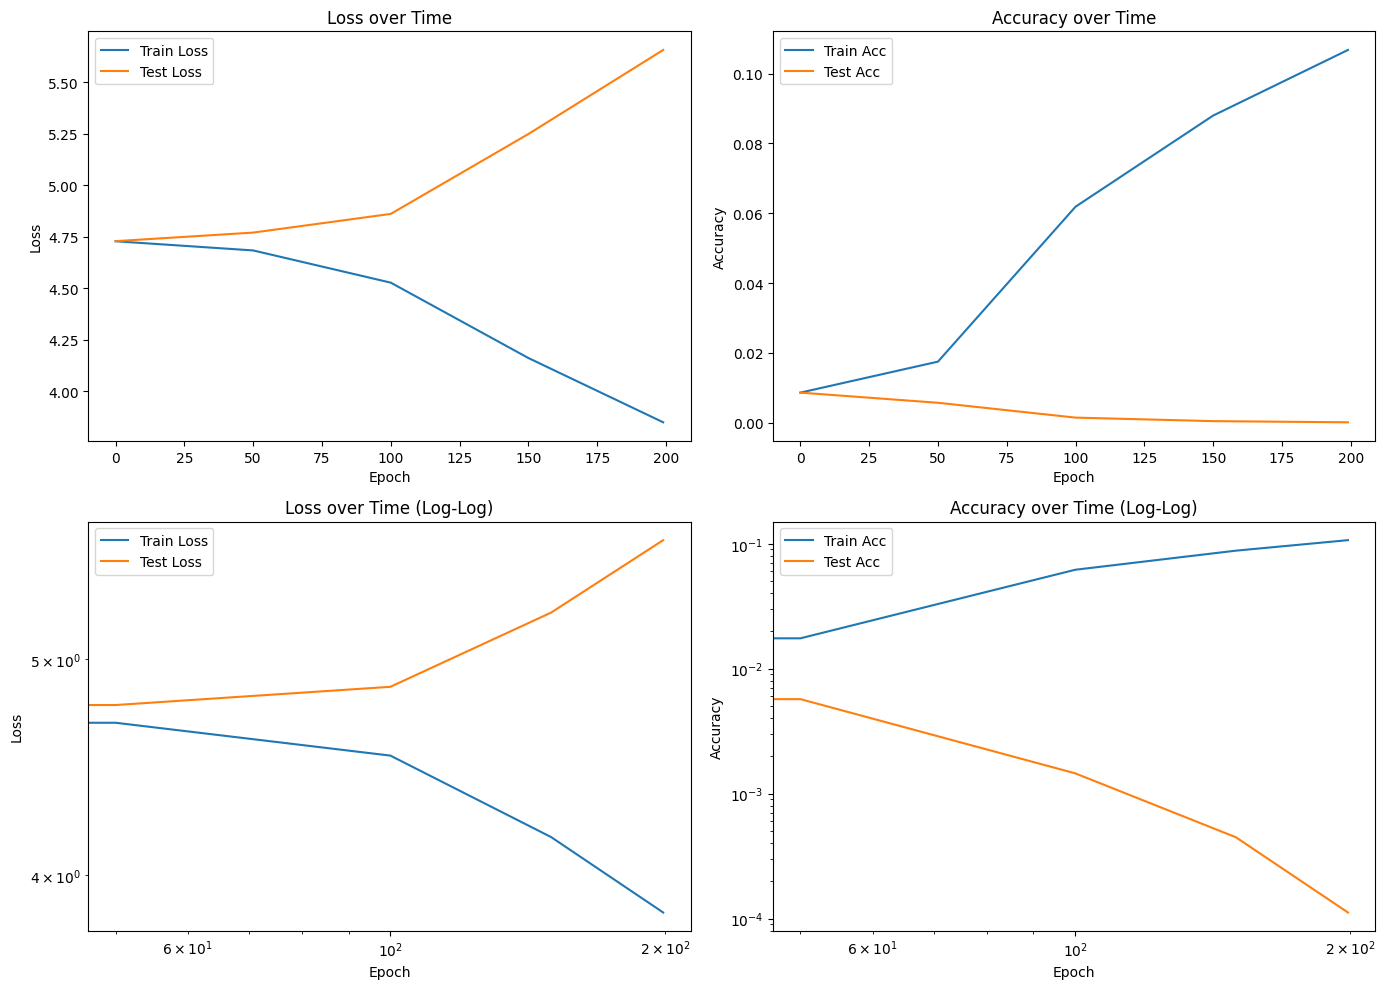

A	results/seed132__epochs200.json
A	results/seed132__epochs200_model.pt
Already on 'tests_core'
Your branch is up to date with 'origin/tests_core'.
[tests_core a7874e1] seed=132, epochs=200
 2 files changed, 1 insertion(+)
 create mode 100644 results/seed132__epochs200.json
 create mode 100644 results/seed132__epochs200_model.pt
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 413.69 KiB | 14.26 MiB/s, done.
Total 5 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/slimisgit/grokking.git
   05c7c92..a7874e1  tests_core -> tests_core


In [14]:
#обучение+тесты (ЛЮБОЙ ЗАПУСК КОМИТИТСЯ, НЕ МЕНЯЙТЕ 2 ГИПЕРПАРАМТРА ОДНОВРЕМЕННО! checkpoint_interval МОЖНО)

#НЕЛЬЗЯ МНОГОГИПЕРПАРАМЕТРОВ
result = train_and_test_with_params(seed=132, epochs=200, checkpoint_interval=50)
graphic(result.train_losses, result.train_accuracies, result.test_losses, result.test_accuracies)

!git add results/
!git checkout tests_core
!git commit -m "seed=132, epochs=200"
!git push origin tests_core

Cloning into 'grokking'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 60 (delta 14), reused 26 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 1.11 MiB | 4.02 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/grokking/grokking/grokking
Branch 'tests_core' set up to track remote branch 'tests_core' from 'origin'.
Switched to a new branch 'tests_core'


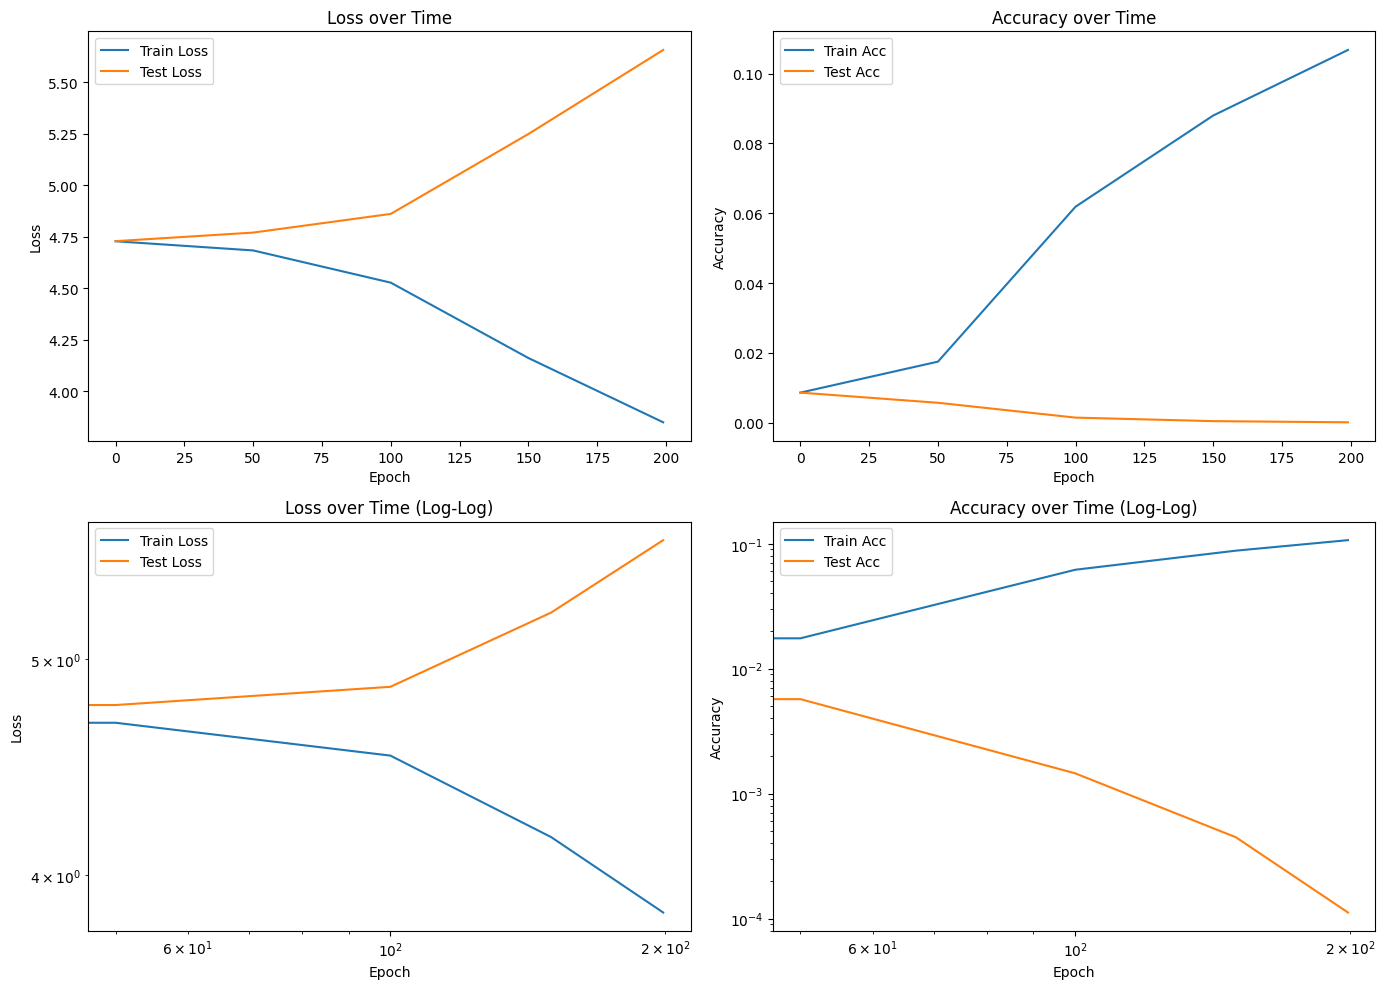

In [16]:
#вывод графиков тестов которые уже были проведены
!git clone https://github.com/slimisgit/grokking.git
%cd grokking
!git checkout tests_core

loaded = Grokking_Data.load("results/seed132__epochs200.json")

graphic(loaded.train_losses, loaded.train_accuracies, loaded.test_losses, loaded.test_accuracies)

Fetching origin
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (2/2), 862 bytes | 862.00 KiB/s, done.
From https://github.com/slimisgit/grokking
   53822f1..05c7c92  new_model  -> origin/new_model
 * [new branch]      tests_core -> origin/tests_core
